#### Summary:
In this notebook we will get some basic summary stats and summary plots for individual links runs from either different cell types or different methods. Additionally to compare all sig and background links merged I'll first make merged links files by cell type.

# 1. Basic Preparation

In [1]:
# Import necessary libraries
suppressMessages(library(tidyverse))
suppressMessages(library(stringr))
suppressMessages(library(data.table))
suppressMessages(library(grid))
suppressMessages(library(tictoc))
suppressMessages(library(pheatmap))
suppressMessages(library(ggplot2))
suppressMessages(library(ggrepel))
suppressMessages(library(UpSetR))

In [2]:
# Define celltypes list
celltypes <- c('beta','alpha','delta','gamma','acinar','ductal')

# Define colors for each celltype (same order as celltypes)
colors <- c('#3F98E0', '#F51646', '#E39E14', '#A1D99B', '#09850B','#F5DE6C')
names(colors) <- celltypes

theme_set(theme_classic())

### Reference files

In [3]:
# Read in all celltype peak files into a list
ct_peaks_list <- list()

for (celltype in celltypes){
    peak.fp <- sprintf('/dir/with/peak/calls/%s.union_peaks.cut.bed',celltype)
    ct.peaks <- read.table(peak.fp,sep='\t')
    ct_peaks <- paste(ct.peaks$V1,ct.peaks$V2,ct.peaks$V3,sep="_")
    ct_peaks_list[[celltype]] = ct_peaks
}

In [4]:
# Read in all celltype lists of TPM > 1 genes
ct_genes_list <- list()
for (celltype in celltypes){
    gene.fp <- sprintf('/dir/with/celltype/TPM/%s_expressed_genes_TPM1.txt',celltype)
    genes <- scan(gene.fp, what = '', sep = '\n')
    ct_genes_list[[celltype]] <- genes
}

In [63]:
# MANE coordinates (to match gene coords to WashU epigenome browser preferred annotation track)
mane_dir <- '/non-diabetic-islet-multiomics/references'
mane_tss_fp <- file.path(mane_dir,'MANE.GRCh38.v1.0.TSS0index.bed')
mane_tss <- read.table(mane_tss_fp, sep='\t')
row.names(mane_tss) <- mane_tss$V4
mane_fin <- mane_tss[,c(1,2,3,4)]
dim(mane_fin)

# Gencode v32 gene coords
gencode_fp <- 'non-diabetic-islet-multiomics/references/gene_coords.gencodev32.hg38.TSS0index.bed'
gencode_tss <- read.table(gencode_fp, sep='\t', header=FALSE) #read in gene coords ref
row.names(gencode_tss) <- gencode_tss$V4
gencode_fin <- gencode_tss[,c(1,2,3,4)]
dim(gencode_fin)

[1] 19062     4

[1] 36549     4

### Establish file naming practices for links files

In [5]:
links_dir <- "/dir/with/cRE-gene/links"

In [6]:
# SMORES method links files = sm_prefix + celltype + '/' + celltype + sm_suffix
sm_prefix1 <- file.path(links_dir,'SMORES/')
sm_suffix1 <- '_mapped_links.bedpe'
sm_prefix2 <- paste0(sm_prefix1,'nonsig_links/')
sm_suffix2 <- '_mapped_links.bedpe'

# SCARlink method links files = sl_prefix + celltype + '/' + celltype + sl_suffix
sl_prefix <- file.path(links_dir,'SCARlink/')
sl_suffix1 <- '_mapped_SIG_links.bedpe'
sl_suffix2 <- '_mapped_BG_links.bedpe'

# ABC links = abc_prefix + '/' + celltype + sl_suffix
abc_prefix1 <- file.path(links_dir,'ABC/')
abc_suffix1 <- '_mapped_links.bedpe'
abc_prefix2 <- paste0(abc_prefix1,'nonsig_links/')
abc_suffix2 <- '_mapped_links.bedpe'

# Processed Cicero links
cic_prefix1 <- file.path(links_dir,'Cicero/')
cic_prefix2 <- paste0(cic_prefix1, 'nonsig_links/')
cic_suffix1 <- '_links.CP_reformat.bedpe'
cic_suffix2 <- '_links.final_filt.bedpe'

In [43]:
overlap_dir <- file.path(links_dir,'combined')

# 2. Create combined link files from all methods

## 2a. Make merged significant links file

### Functions

In [7]:
### Function to process links into a common format list
get_formatted_links <- function(row){
    cre = paste(row[[1]],row[[2]],row[[3]],sep='-')
    gene = row[[7]]
    return(paste(cre,gene,sep="_"))
}

In [65]:
### Function to compare the celltype links from all methods using Upset (returns upset object for further work)
### Also writes outputs to files (using _ not - or & to separate link method names!!!)

### New method that makes combined bedpe for all sig links per cell type (with info on which methods they were called in)
merge_links <- function(celltype, tss_df, overlap_outdir, prefix='sig'){
    # Set up file paths for each links set
    if(prefix=='sig'){
        sm_fp <- paste0(sm_prefix1, celltype, sm_suffix1)
        sl_fp <- paste0(sl_prefix, celltype, sl_suffix1)
        abc_fp <- paste0(abc_prefix1, celltype, abc_suffix1)
        cic_fp <- paste0(cic_prefix1, celltype, cic_suffix1)
    } else if(prefix=='bg'){
        sm_fp <- paste0(sm_prefix2, celltype, sm_suffix2)
        sl_fp <- paste0(sl_prefix, celltype, sl_suffix2)
        abc_fp <- paste0(abc_prefix2, celltype, abc_suffix2)
        cic_fp <- paste0(cic_prefix2, celltype, cic_suffix2)
    }
    
    # Read in links and convert to basic format (add links info back to dfs for use later)
    sm_df <- read.table(sm_fp, sep='\t')
    sm_links <- gsub(" ","",apply(sm_df, 1, get_formatted_links))
    sm_df$links <- sm_links
    print(paste0('Total number of SMORES links: ', length(sm_links)))
    sl_df <- read.table(sl_fp, sep='\t')
    sl_links <- gsub(" ","",apply(sl_df, 1, get_formatted_links))
    sl_df$links <- sl_links
    print(paste0('Total number of SCARlink links: ', length(sl_links)))
    abc_df <- read.table(abc_fp, sep='\t')
    abc_links <- gsub(" ","",apply(abc_df, 1, get_formatted_links))
    abc_df$links <- abc_links
    print(paste0('Total number of ABC links: ', length(abc_links)))
    cic_df <- read.table(cic_fp, sep='\t')
    cic_links <- gsub(" ","",apply(cic_df, 1, get_formatted_links))
    cic_df$links <- cic_links
    print(paste0('Total number of Cicero links: ', length(cic_links)))
    
    # Make Upset plot object and pull out links overlap table
    listInput <- list(sm = sm_links, sl = sl_links, abc = abc_links, cic=cic_links)
    p1 <- upset(fromList(listInput), order.by = "degree", sets.x.label="Links datasets")
    overlaps <- p1$New_data
    all_links <- unlist(listInput, use.names=FALSE)
    all_links <- all_links[!duplicated(all_links)]
    row.names(overlaps) <- all_links
    
    # Get cRE coords into columns
    all_links_coords <- str_split_fixed(all_links,'_',2)[,1]
    coords <- str_split_fixed(all_links_coords, '-', 3)
    colnames(coords) <- c('chr','start','end')
    overlaps_fin <- cbind(coords, overlaps)

    # Get gene coords from the MANE TSS df (and gencode one as backup)
    overlaps_fin$gene <- str_split_fixed(row.names(overlaps_fin),'_',2)[,2]
    overlaps_fin1 <- subset(overlaps_fin, gene %in% mane_fin$V4)
    overlaps_fin2 <- subset(overlaps_fin, !gene %in% mane_fin$V4)
    bedpe1 <- cbind(overlaps_fin1[,c(1,2,3)], mane_fin[overlaps_fin1$gene,], overlaps_fin1[,c(7,4,5,6)]) 
    bedpe2 <- cbind(overlaps_fin2[,c(1,2,3)], gencode_fin[overlaps_fin2$gene,], overlaps_fin2[,c(7,4,5,6)])
    bedpe <- rbind(bedpe1,bedpe2)

    # Just set all link scores to 1 for genome browser plotting (not worthwhile keeping that info in this df)
    bedpe$score <- 1
    
    # Add column with string of which method/s called the link
    methods <- c('sm_sl_abc_cic', 
                 'sm_sl_abc','sm_sl_cic','sm_abc_cic','sl_abc_cic',
                 'sm_sl','sm_abc','sm_cic','sl_abc','sl_cic','abc_cic',
                 'sm','sl','abc','cic')
    names(methods) <- c('1111','1110','1101','1011','0111',
                        '1100','1010','1001','0110','0101','0011',
                        '1000','0100','0010','0001')
    methods_bin <- paste0(as.character(bedpe$sm),as.character(bedpe$sl),as.character(bedpe$abc),as.character(bedpe$cic))
    bedpe$method_str <- methods[methods_bin]
    print(paste0('Total number of unique links: ', dim(bedpe)[1]))

    #rm binary columns and write to file
    bedpe_fin <- bedpe[,c(1,2,3,4,5,6,7,12,13)] 
    fp <- file.path(overlap_outdir,sprintf('%s_all_methods_%s_links.bedpe',celltype, prefix))
    write.table(bedpe_fin,fp,sep='\t',row.names=F,col.names=F,quote=F)
}

In [67]:
for(celltype in celltypes){
    print(celltype)
    merge_links(celltype, mane_fin, overlap_dir, 'sig')
    print('')
}

[1] "beta"
[1] "Total number of SMORES links: 43487"
[1] "Total number of SCARlink links: 11218"
[1] "Total number of ABC links: 29333"
[1] "Total number of Cicero links: 14193"
[1] "Total number of unique links: 87570"
[1] ""
[1] "alpha"
[1] "Total number of SMORES links: 27881"
[1] "Total number of SCARlink links: 9774"
[1] "Total number of ABC links: 30967"
[1] "Total number of Cicero links: 16618"
[1] "Total number of unique links: 77426"
[1] ""
[1] "delta"
[1] "Total number of SMORES links: 11616"
[1] "Total number of SCARlink links: 2918"
[1] "Total number of ABC links: 30269"
[1] "Total number of Cicero links: 12511"
[1] "Total number of unique links: 54034"
[1] ""
[1] "gamma"
[1] "Total number of SMORES links: 9647"
[1] "Total number of SCARlink links: 1492"
[1] "Total number of ABC links: 30333"
[1] "Total number of Cicero links: 24052"
[1] "Total number of unique links: 61933"
[1] ""
[1] "acinar"
[1] "Total number of SMORES links: 16741"
[1] "Total number of SCARlink links: 5

## 2b. Merge the background link sets file

In [68]:
for(celltype in celltypes){
    print(celltype)
    merge_links(celltype, mane_fin, overlap_dir, 'bg')
    print('')
}

[1] "beta"
[1] "Total number of SMORES links: 496362"
[1] "Total number of SCARlink links: 262118"
[1] "Total number of ABC links: 499716"
[1] "Total number of Cicero links: 272950"
[1] "Total number of unique links: 665289"
[1] ""
[1] "alpha"
[1] "Total number of SMORES links: 548602"
[1] "Total number of SCARlink links: 274401"
[1] "Total number of ABC links: 550491"
[1] "Total number of Cicero links: 290111"
[1] "Total number of unique links: 728213"
[1] ""
[1] "delta"
[1] "Total number of SMORES links: 530220"
[1] "Total number of SCARlink links: 271929"
[1] "Total number of ABC links: 542180"
[1] "Total number of Cicero links: 269516"
[1] "Total number of unique links: 714267"
[1] ""
[1] "gamma"
[1] "Total number of SMORES links: 523162"
[1] "Total number of SCARlink links: 274267"
[1] "Total number of ABC links: 544259"
[1] "Total number of Cicero links: 261833"
[1] "Total number of unique links: 704264"
[1] ""
[1] "acinar"
[1] "Total number of SMORES links: 493801"
[1] "Total nu

# 3. Summary Stats

### Functions

In [70]:
### Function get summary stats for any links output for a celltype
### Just needs the paths for all tested links and all significant links, 
### colnames for both and reference files

summarize_links <- function(all_links_fp, all_links_colnames, header1, 
                            signif_links_fp, signif_links_colnames, header2,
                            ct_peaks_list, ct_genes_list){
    # Read in files, add colnames if no header
    if (header1 == FALSE){
        all_links_df <- read.table(all_links_fp, sep='\t')
        colnames(all_links_df) <- all_links_colnames
    } else {
        all_links_df <- read.table(all_links_fp, sep='\t', header=TRUE)
    }
    if (header2 == FALSE){
        signif_links_df <- read.table(signif_links_fp, sep='\t')
        colnames(signif_links_df) <- signif_links_colnames        
    } else {
        signif_links_df <- read.table(signif_links_fp, sep='\t', header=TRUE)
    }
    
    # Get # links stats
    signif_links <- dim(signif_links_df)[1]
    nonsignif_links <- dim(all_links_df)[1]
    total_links <- dim(all_links_df)[1] + dim(signif_links_df)[1]
    percent_signif <- signif_links/total_links
    min_score <- min(signif_links_df$score)
    max_score <- max(signif_links_df$score)
    
    # Get number of unique linked genes and CREs
    linked_genes <- length(unique(signif_links_df$gene))
    total_CT_genes <- length(ct_genes_list[[celltype]])
    percent_genes_linked <- linked_genes/total_CT_genes
    
    CREs <- paste(signif_links_df$chr1, signif_links_df$start1, signif_links_df$end1, sep='-')
    linked_CREs <- length(unique(CREs))
    total_CT_CREs <- length(ct_peaks_list[[celltype]])
    percent_CREs_linked <- linked_CREs/total_CT_CREs
    
    # Organize outputs into a dataframe with one row
    out_df <- data.frame(signif_links, nonsignif_links, total_links, percent_signif, min_score, max_score,
                         linked_genes, total_CT_genes, percent_genes_linked,
                         linked_CREs, total_CT_CREs, percent_CREs_linked)
    return(out_df)
}

### Run functions to get basic summary stats for all links (various methods)

In [71]:
# Get SMORES summary dataframe for all celltypes
smores_summary_df <- data.frame()
for (celltype in celltypes){
    all_links_fp <- paste0(sm_prefix2, celltype, sm_suffix2)
    colnames1 <- c('chr1','start1','end1','chr2','start2','end2','gene','score')
    signif_fp <- paste0(sm_prefix1, celltype, sm_suffix1)
    colnames2 <- c('chr1','start1','end1','chr2','start2','end2','gene','score')
    
    ct_df_row <- summarize_links(all_links_fp, colnames1, FALSE, signif_fp, colnames2, FALSE, ct_peaks_list, ct_genes_list)
    smores_summary_df <- rbind(smores_summary_df, ct_df_row)
}

rownames(smores_summary_df) <- celltypes
smores_summary_df

out_fp <- paste0(sm_prefix1,'celltypes_results_summary.txt')
write.table(smores_summary_df, out_fp, sep='\t', row.names = TRUE, col.names = TRUE, quote=FALSE)

,signif_links,nonsignif_links,total_links,percent_signif,min_score,max_score,linked_genes,total_CT_genes,percent_genes_linked,linked_CREs,total_CT_CREs,percent_CREs_linked
,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
beta,43487,496362,539849,0.08055401,-0.12247070,0.3615305,11301,20295,0.5568367,32720,128874,0.25389140
alpha,27881,548602,576483,0.04836396,-0.06918043,0.3076519,10057,21432,0.4692516,22598,131136,0.17232491
delta,11616,530220,541836,0.02143822,-0.10553368,0.2921575,7338,21789,0.3367754,10557,130800,0.08071101
gamma,9647,523162,532809,0.01810593,-0.07248211,0.3564551,6520,21252,0.3067947,8887,125951,0.07055919
acinar,16741,493801,510542,0.03279064,-0.09501333,0.2401967,7989,19715,0.4052244,14558,124160,0.11725193
ductal,18709,642414,661123,0.02829882,-0.08599286,0.3450560,9609,23857,0.4027749,16447,134672,0.12212635


In [9]:
# Get SCARlink summary dataframe for all celltypes
scarlink_summary_df <- data.frame()
for (celltype in celltypes){
    all_links_fp <- paste0(sl_prefix, celltype, sl_suffix2)
    colnames1 <- c('chr1','start1','end1','chr2','start2','end2','gene','score')
    signif_fp <- paste0(sl_prefix, celltype, sl_suffix1)
    colnames2 <- c('chr1','start1','end1','chr2','start2','end2','gene','score')
    
    ct_df_row <- summarize_links(all_links_fp, colnames1, FALSE, signif_fp, colnames2, FALSE, ct_peaks_list, ct_genes_list)
    scarlink_summary_df <- rbind(scarlink_summary_df, ct_df_row)
}

rownames(scarlink_summary_df) <- celltypes
scarlink_summary_df

out_fp <- paste0(sl_prefix,'celltypes_results_summary.txt')
write.table(scarlink_summary_df, out_fp, sep='\t', row.names = TRUE, col.names = TRUE, quote=FALSE)

,signif_links,nonsignif_links,total_links,percent_signif,min_score,max_score,linked_genes,total_CT_genes,percent_genes_linked,linked_CREs,total_CT_CREs,percent_CREs_linked
,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
beta,11218,262118,273336,0.041041063,2.744099e-06,0.1968042,1334,20295,0.06573048,9975,128874,0.07740118
alpha,9774,274401,284175,0.034394299,3.424274e-06,0.1994417,1309,21432,0.06107689,8787,131136,0.06700677
delta,2918,271929,274847,0.010616816,5.656573e-06,0.1968042,1095,21789,0.05025472,2590,130800,0.01980122
gamma,1492,274267,275759,0.005410522,9.945057e-06,0.1968042,770,21252,0.03623188,1332,125951,0.01057554
acinar,5799,261672,267471,0.021680855,2.016393e-06,0.1968042,1114,19715,0.05650520,5248,124160,0.04226804
ductal,2963,282703,285666,0.010372253,1.706076e-06,0.1968042,955,23857,0.04003018,2687,134672,0.01995218


In [20]:
# Get ABC summary dataframe for all celltypes
abc_summary_df <- data.frame()
for (celltype in celltypes){
    all_links_fp <- paste0(abc_prefix2, celltype, abc_suffix2)
    colnames1 <- c('chr1','start1','end1','chr2','start2','end2','gene','score')
    signif_fp <- paste0(abc_prefix1, celltype, abc_suffix1)
    colnames2 <- c('chr1','start1','end1','chr2','start2','end2','gene','score')
    
    ct_df_row <- summarize_links(all_links_fp, colnames1, FALSE, signif_fp, colnames2, FALSE, ct_peaks_list, ct_genes_list)
    abc_summary_df <- rbind(abc_summary_df, ct_df_row)
}

rownames(abc_summary_df) <- celltypes
abc_summary_df

out_fp <- paste0(abc_prefix1,'celltypes_results_summary.txt')
write.table(abc_summary_df, out_fp, sep='\t', row.names = TRUE, col.names = TRUE, quote=FALSE)

,signif_links,nonsignif_links,total_links,percent_signif,min_score,max_score,linked_genes,total_CT_genes,percent_genes_linked,linked_CREs,total_CT_CREs,percent_CREs_linked
,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
beta,29333,499716,529049,0.05544477,0.02,0.733454,13567,20295,0.6684898,12738,128874,0.09884073
alpha,30967,550491,581458,0.05325750,0.02,0.726580,14319,21432,0.6681131,13587,131136,0.10360999
delta,30269,542180,572449,0.05287633,0.02,0.711576,14327,21789,0.6575336,12972,130800,0.09917431
gamma,30333,544259,574592,0.05279050,0.02,0.706296,14188,21252,0.6676078,13117,125951,0.10414367
ductal,39377,686711,726088,0.05423172,0.02,0.686640,16749,23857,0.7020581,15360,134672,0.11405489
acinar,34907,506836,541743,0.06443461,0.02,0.617767,14540,19715,0.7375095,14445,124160,0.11634182


In [77]:
# Get Cicero summary dataframe for all celltypes
cic_summary_df <- data.frame()
for (celltype in celltypes){
    all_links_fp <- paste0(cic_prefix2, celltype, cic_suffix2)
    colnames1 <- c('chr1','start1','end1','chr2','start2','end2','score')
    signif_fp <- paste0(cic_prefix1, celltype, cic_suffix1)
    colnames2 <- c('chr1','start1','end1','chr2','start2','end2','gene','score')
    
    ct_df_row <- summarize_links(all_links_fp, colnames1, FALSE, signif_fp, colnames2, FALSE, ct_peaks_list, ct_genes_list)
    cic_summary_df <- rbind(cic_summary_df, ct_df_row)
}

rownames(cic_summary_df) <- celltypes
cic_summary_df

out_fp <- file.path(cic_prefix1,'celltypes_results_summary.txt')
write.table(cic_summary_df, out_fp, sep='\t', row.names = TRUE, col.names = TRUE, quote=FALSE)

,signif_links,nonsignif_links,total_links,percent_signif,min_score,max_score,linked_genes,total_CT_genes,percent_genes_linked,linked_CREs,total_CT_CREs,percent_CREs_linked
,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
beta,14193,272950,287143,0.04942833,0.05000090,0.7955653,4596,20295,0.2264597,6206,128874,0.04815556
alpha,16618,290111,306729,0.05417812,0.05000335,0.7280902,5109,21432,0.2383819,7204,131136,0.05493533
delta,12511,269516,282027,0.04436100,0.05000043,0.7401127,6109,21789,0.2803708,9222,130800,0.07050459
gamma,24052,261833,285885,0.08413173,0.05000163,0.6724025,6656,21252,0.3131941,11443,125951,0.09085279
acinar,10022,268883,278905,0.03593338,0.05000022,0.7611411,4794,19715,0.2431651,6688,124160,0.05386598
ductal,34350,304403,338753,0.10140132,0.05000014,0.7626768,7354,23857,0.3082533,13531,134672,0.10047374


In [78]:
# GET ALL links summary dataframe for all celltypes
all_summary_df <- data.frame()
for (celltype in celltypes){
    all_links_fp <- file.path(overlap_dir, sprintf('%s_all_methods_bg_links.bedpe',celltype))
    colnames1 <- c('chr1','start1','end1','chr2','start2','end2','gene','score','methods')
    signif_fp <- file.path(overlap_dir, sprintf('%s_all_methods_sig_links.bedpe',celltype))
    colnames2 <- c('chr1','start1','end1','chr2','start2','end2','gene','score','methods')
    
    ct_df_row <- summarize_links(all_links_fp, colnames1, FALSE, signif_fp, colnames2, FALSE, ct_peaks_list, ct_genes_list)
    all_summary_df <- rbind(all_summary_df, ct_df_row)
}

rownames(all_summary_df) <- celltypes
all_summary_df

out_fp <- file.path(overlap_dir,'celltypes_results_summary.txt')
write.table(all_summary_df, out_fp, sep='\t', row.names = TRUE, col.names = TRUE, quote=FALSE)

,signif_links,nonsignif_links,total_links,percent_signif,min_score,max_score,linked_genes,total_CT_genes,percent_genes_linked,linked_CREs,total_CT_CREs,percent_CREs_linked
,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
beta,87570,665289,752859,0.11631660,1,1,17424,20295,0.8585366,47475,128874,0.3683831
alpha,77426,728213,805639,0.09610508,1,1,17922,21432,0.8362262,40584,131136,0.3094802
delta,54034,714267,768301,0.07032921,1,1,17679,21789,0.8113727,29203,130800,0.2232645
gamma,61933,704264,766197,0.08083169,1,1,17370,21252,0.8173348,28850,125951,0.2290573
acinar,61610,658377,719987,0.08557099,1,1,16864,19715,0.8553893,32288,124160,0.2600515
ductal,89390,840537,929927,0.09612582,1,1,20311,23857,0.8513644,38866,134672,0.2885975


# 4. Compare # links with # cells in celltype

In [72]:
### Function to plot the number of links compared to the # of cells by cell type
plot_num_link_comp <- function(sig_prefix, sig_suffix, method_name){
    # Get the number of BCs in each celltype
    counts_fp <- '/dir/with/celltype/counts/table/28sample_combined.noDoublets.QCfilters.ATAC_peaks.FINAL_v2.celltype_counts.txt'
    counts_df <- read.table(counts_fp,sep='\t',header = FALSE)
    colnames(counts_df) <- c('celltype','count')
    rownames(counts_df) <- counts_df$celltype
    counts_df <- counts_df[celltypes,]

    # Get the total number of unique links found for each celltype
    num_links <- list()
    for(celltype in celltypes){
        links_fp <- paste0(sig_prefix, celltype, sig_suffix)
        links <- read.table(links_fp, sep='\t', header=FALSE)    
        num_links[[celltype]] <- dim(links)[1]
    }

    # Add information into counts_df 
    counts_df$links <- unlist(num_links)
    counts_df$color <- colors
    print(counts_df)

    # Plot dotplot with ggplot
    options(repr.plot.width=8, repr.plot.height=8)
    col <- as.character(counts_df$color)
    names(col) <- as.character(counts_df$celltype)
    
    p1 <- ggplot(counts_df, aes(x=count, y=links)) + 
            geom_point(size=6, aes(colour=celltype)) + 
            labs(x = "Number of Cells", y = "Number of Links", color="Cell Type", title=method_name) + 
            scale_color_manual(values=col) + scale_y_continuous(limits=c(0,60000)) +
            theme(axis.text.x=element_text(size=20, vjust=0.5),
            axis.text.y=element_text(size=20, vjust=0.5),
                axis.title.x = element_text(size=25, vjust=-0.35),
                axis.title.y = element_text(size=25, vjust=0.5),
                plot.title = element_text(size=25, hjust=0.5, face="bold"),
                legend.position = "none")
    print(p1)
}

       celltype count links   color
beta       beta 81100 43487 #3F98E0
alpha     alpha 44500 27881 #F51646
delta     delta  8911 11616 #E39E14
gamma     gamma  5504  9647 #A1D99B
acinar   acinar 27387 16741 #09850B
ductal   ductal  5452 18709 #F5DE6C
       celltype count links   color
beta       beta 81100 11218 #3F98E0
alpha     alpha 44500  9774 #F51646
delta     delta  8911  2918 #E39E14
gamma     gamma  5504  1492 #A1D99B
acinar   acinar 27387  5799 #09850B
ductal   ductal  5452  2963 #F5DE6C


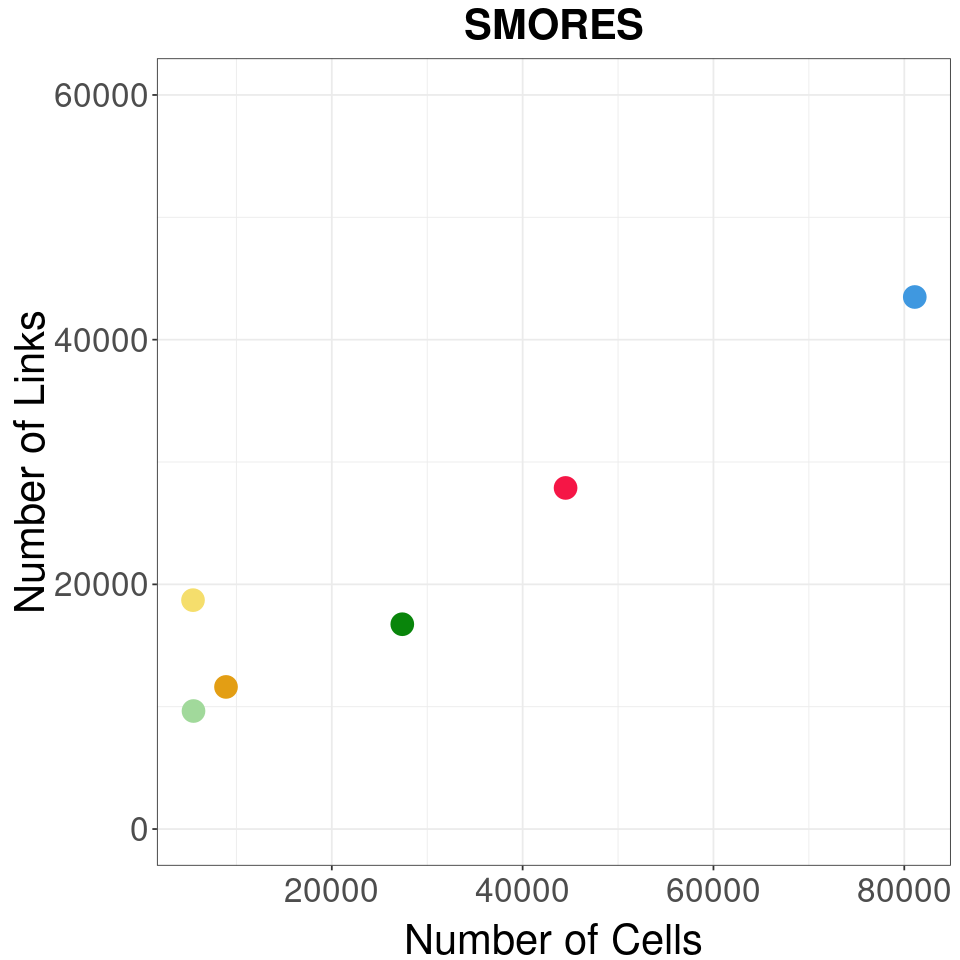

       celltype count links   color
beta       beta 81100 29333 #3F98E0
alpha     alpha 44500 30967 #F51646
delta     delta  8911 30269 #E39E14
gamma     gamma  5504 30333 #A1D99B
acinar   acinar 27387 34907 #09850B
ductal   ductal  5452 39377 #F5DE6C


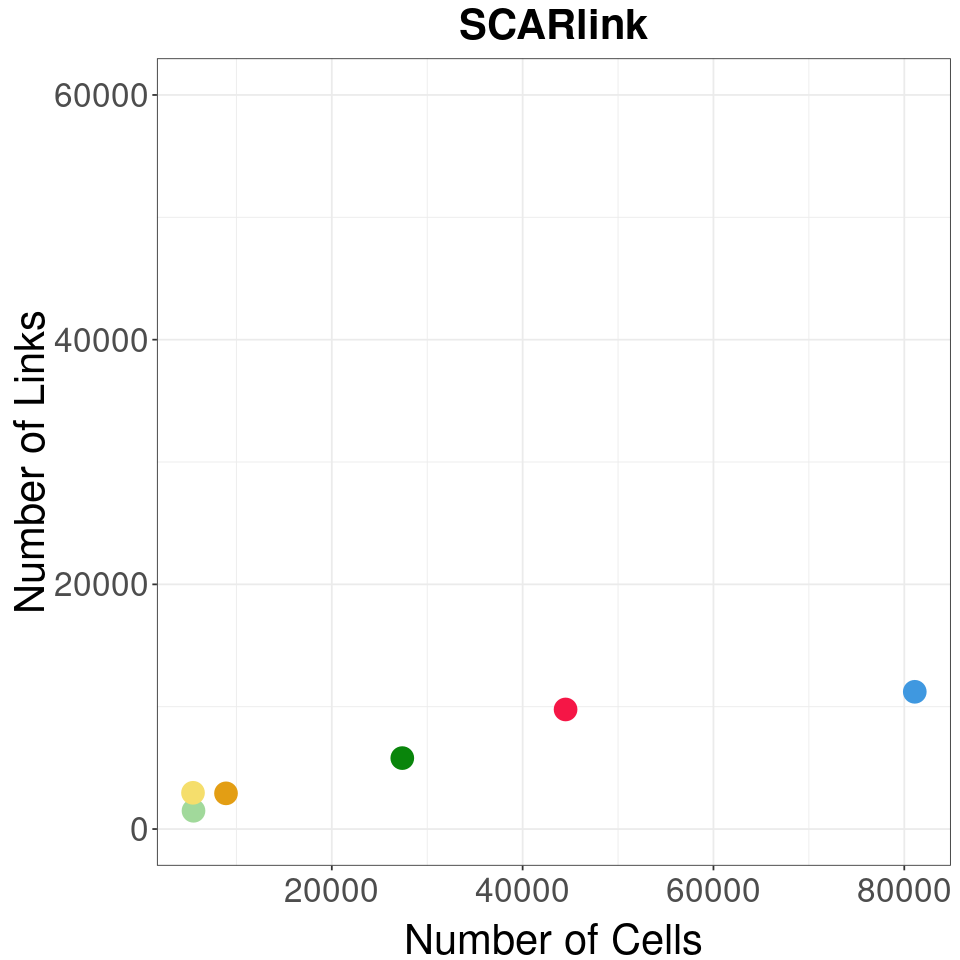

       celltype count links   color
beta       beta 81100 14193 #3F98E0
alpha     alpha 44500 16618 #F51646
delta     delta  8911 12511 #E39E14
gamma     gamma  5504 24052 #A1D99B
acinar   acinar 27387 10022 #09850B
ductal   ductal  5452 34350 #F5DE6C


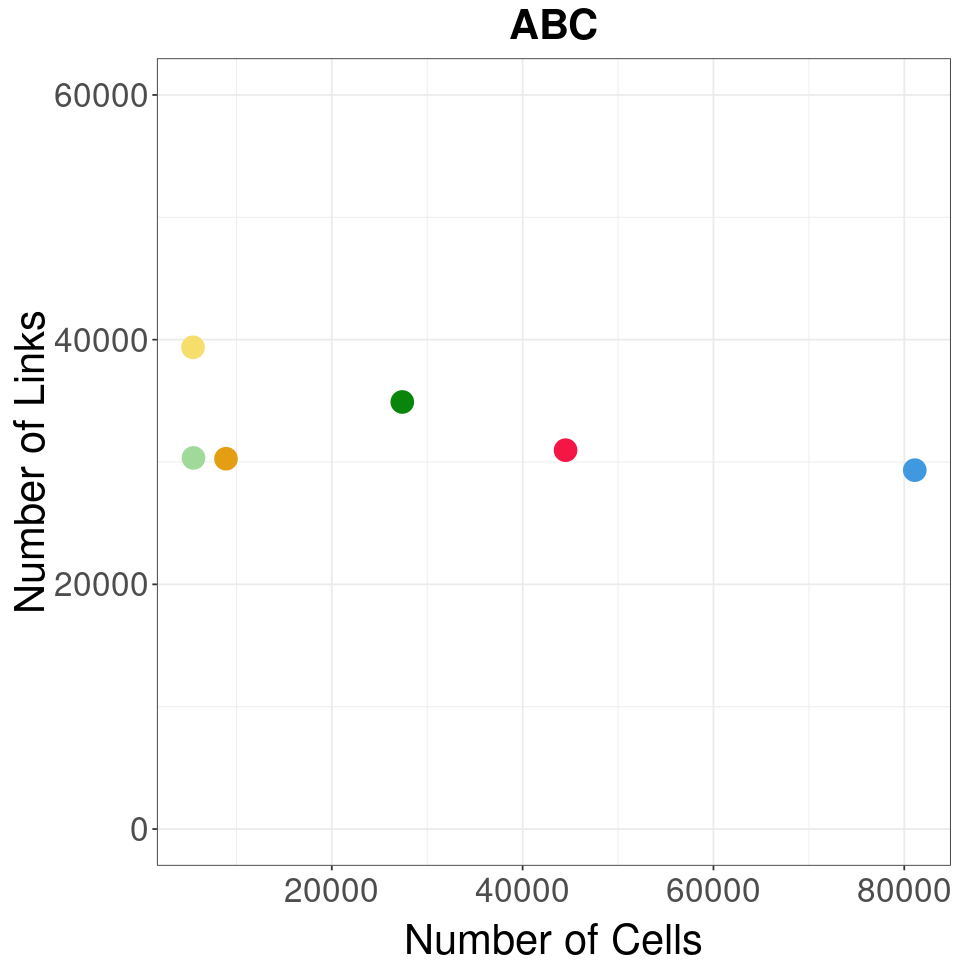

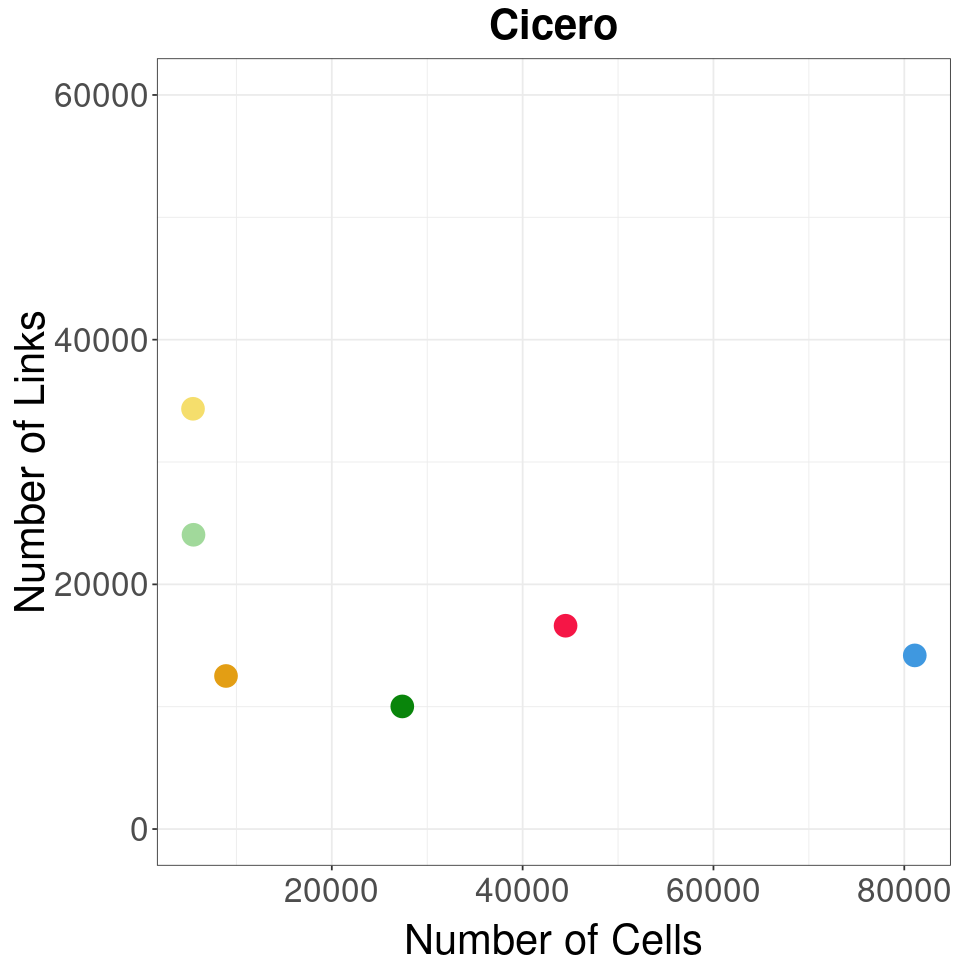

In [73]:
theme_set(theme_bw())
plot_num_link_comp(sm_prefix1, sm_suffix1, 'SMORES')
plot_num_link_comp(sl_prefix, sl_suffix1, 'SCARlink')
plot_num_link_comp(abc_prefix1, abc_suffix1, 'ABC')
plot_num_link_comp(cic_prefix1, cic_suffix1, 'Cicero')

# 5. Overlap links sets between cell types

### Functions

In [74]:
### Function to process links into a common format list
get_formatted_links <- function(row, keep_genes){
    cre = paste(row[[1]],row[[2]],row[[3]],sep='-')
    gene = row[[7]]
    return(paste(cre,gene,sep="_"))
}


### Function to get the named list of link sets for Upset input
make_links_list <- function(celltypes, prefix, suffix, keep_genes){
    listInput <- list()
    for (celltype in celltypes){
        links_fp <- paste0(prefix, celltype, suffix)
        links_df <- read.table(links_fp, sep='\t', header=FALSE)
        links <- gsub(" ","",apply(links_df, 1, get_formatted_links))
        listInput[[celltype]] <- links
    }
    return(listInput)
}

In [75]:
upset_plot_wrapper <- function(method_name, sig_prefix, sig_suffix, nintersects=40){
    # Prepare list of links for Upset
    upsetInput <- make_links_list(celltypes, sig_prefix, sig_suffix)

    #pull out group order ahead of time to make colors vector
    overlap_key <- c('100000'='beta','010000'='alpha','001000'='delta','000100'='gamma','000010'='acinar','000001'='ductal')
    overlaps <- upset(fromList(upsetInput), sets=celltypes[c(1,2,3,4,5,6)], order.by="freq")$New_data
    overlaps <- overlaps %>% mutate(num_overlaps=beta+alpha+delta+gamma+acinar+ductal, overlap_group=paste0(beta,alpha,delta,gamma,acinar,ductal)) %>%
                    group_by(overlap_group) %>%
                    summarize(n=n()) %>% arrange(-n) %>%
                    mutate(celltype=ifelse(overlap_group %in% names(overlap_key), overlap_key[overlap_group], 'mixed')) %>%
                    mutate(color=ifelse(celltype %in% names(colors), colors[celltype], '#858585'))
    upset_colors <- overlaps$color
    
    #finally actually make the plot
    # Make an Upset plot
    options(repr.plot.width=24, repr.plot.height=8)
    p1 <- upset(fromList(upsetInput), sets=celltypes[c(1,2,3,4,5,6)], order.by="freq",            
                sets.x.label="Links datasets", nintersects=nintersects,
                text.scale=c(1.5,1.5,1.5,1.5,2,2), point.size=5, line.size=2,
                main.bar.color=upset_colors) 
    print(p1)
}

### Use functions to overlap links sets, then make an Upset plot

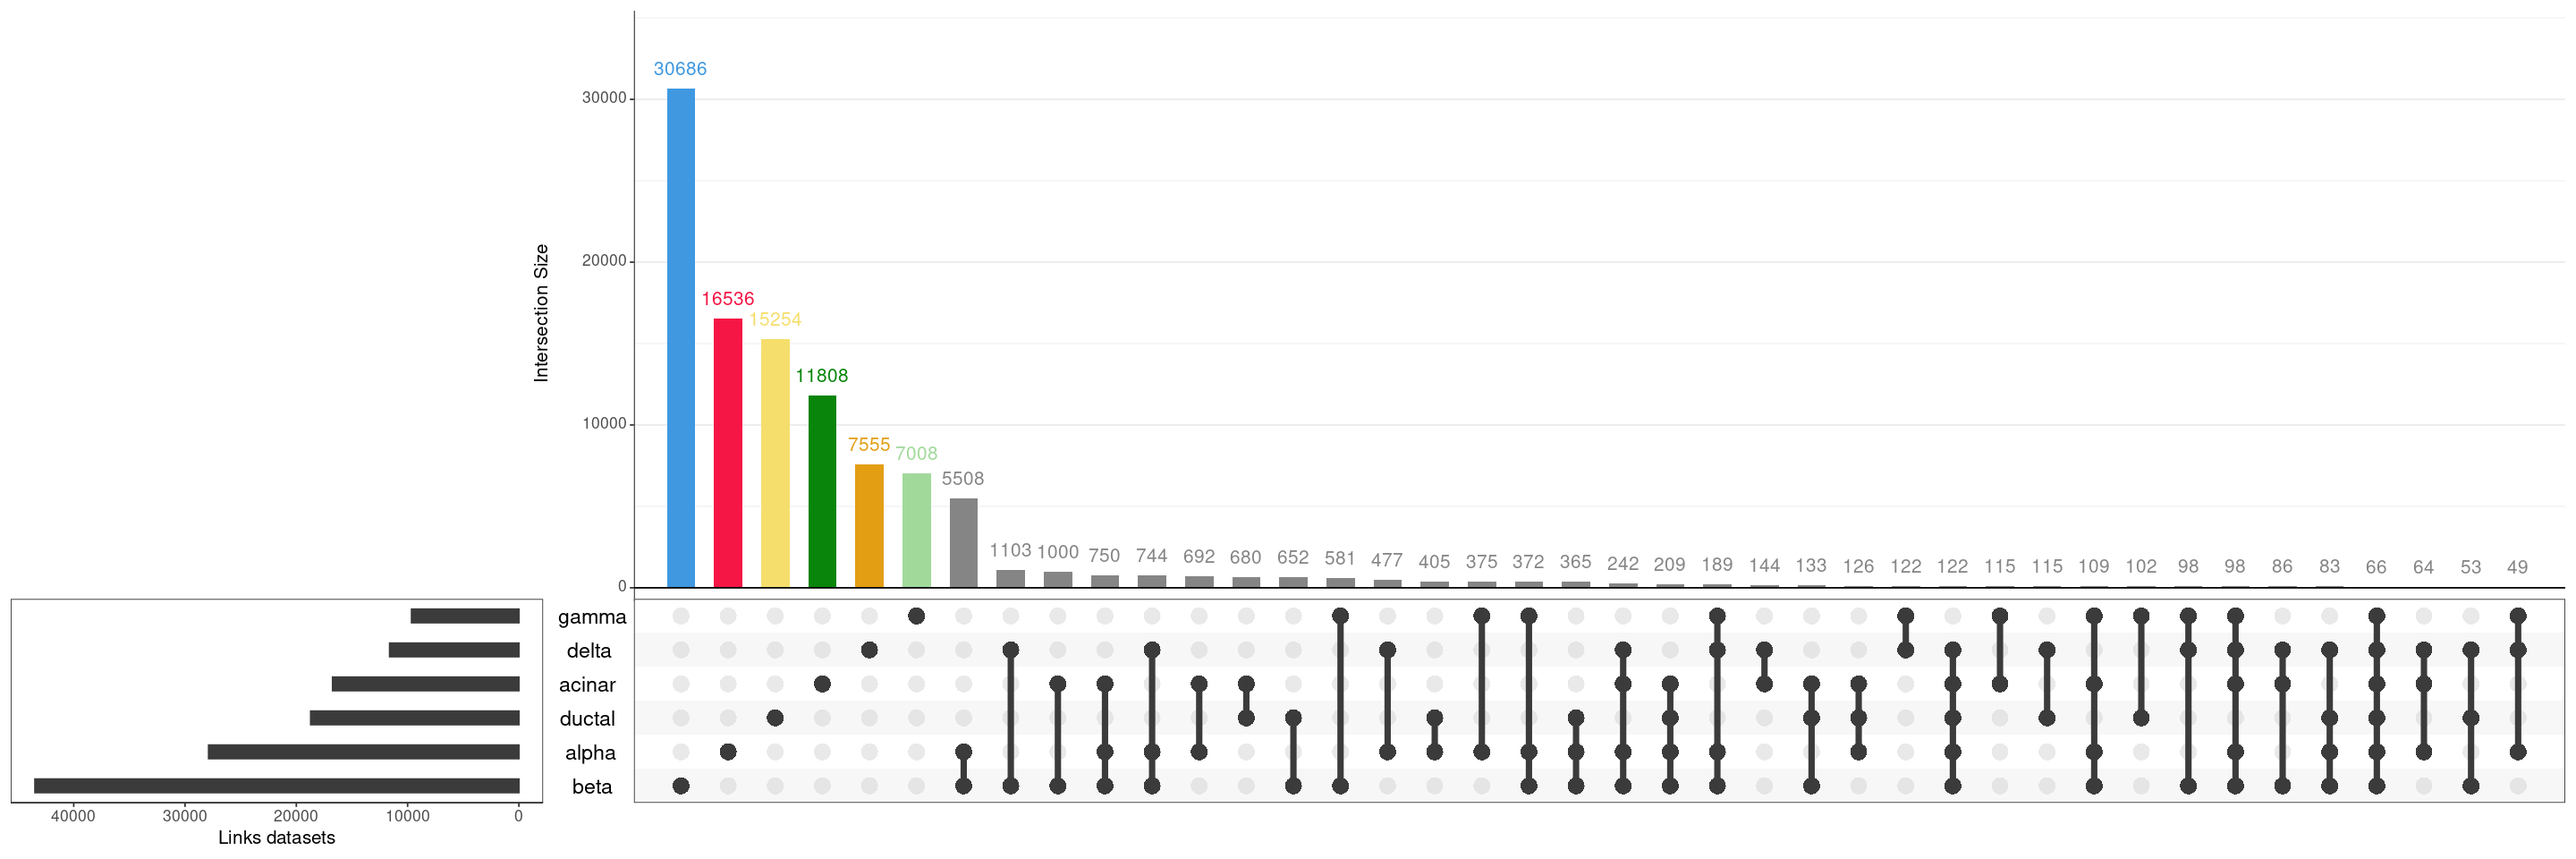

In [76]:
upset_plot_wrapper('SMORES', sm_prefix1, sm_suffix1)

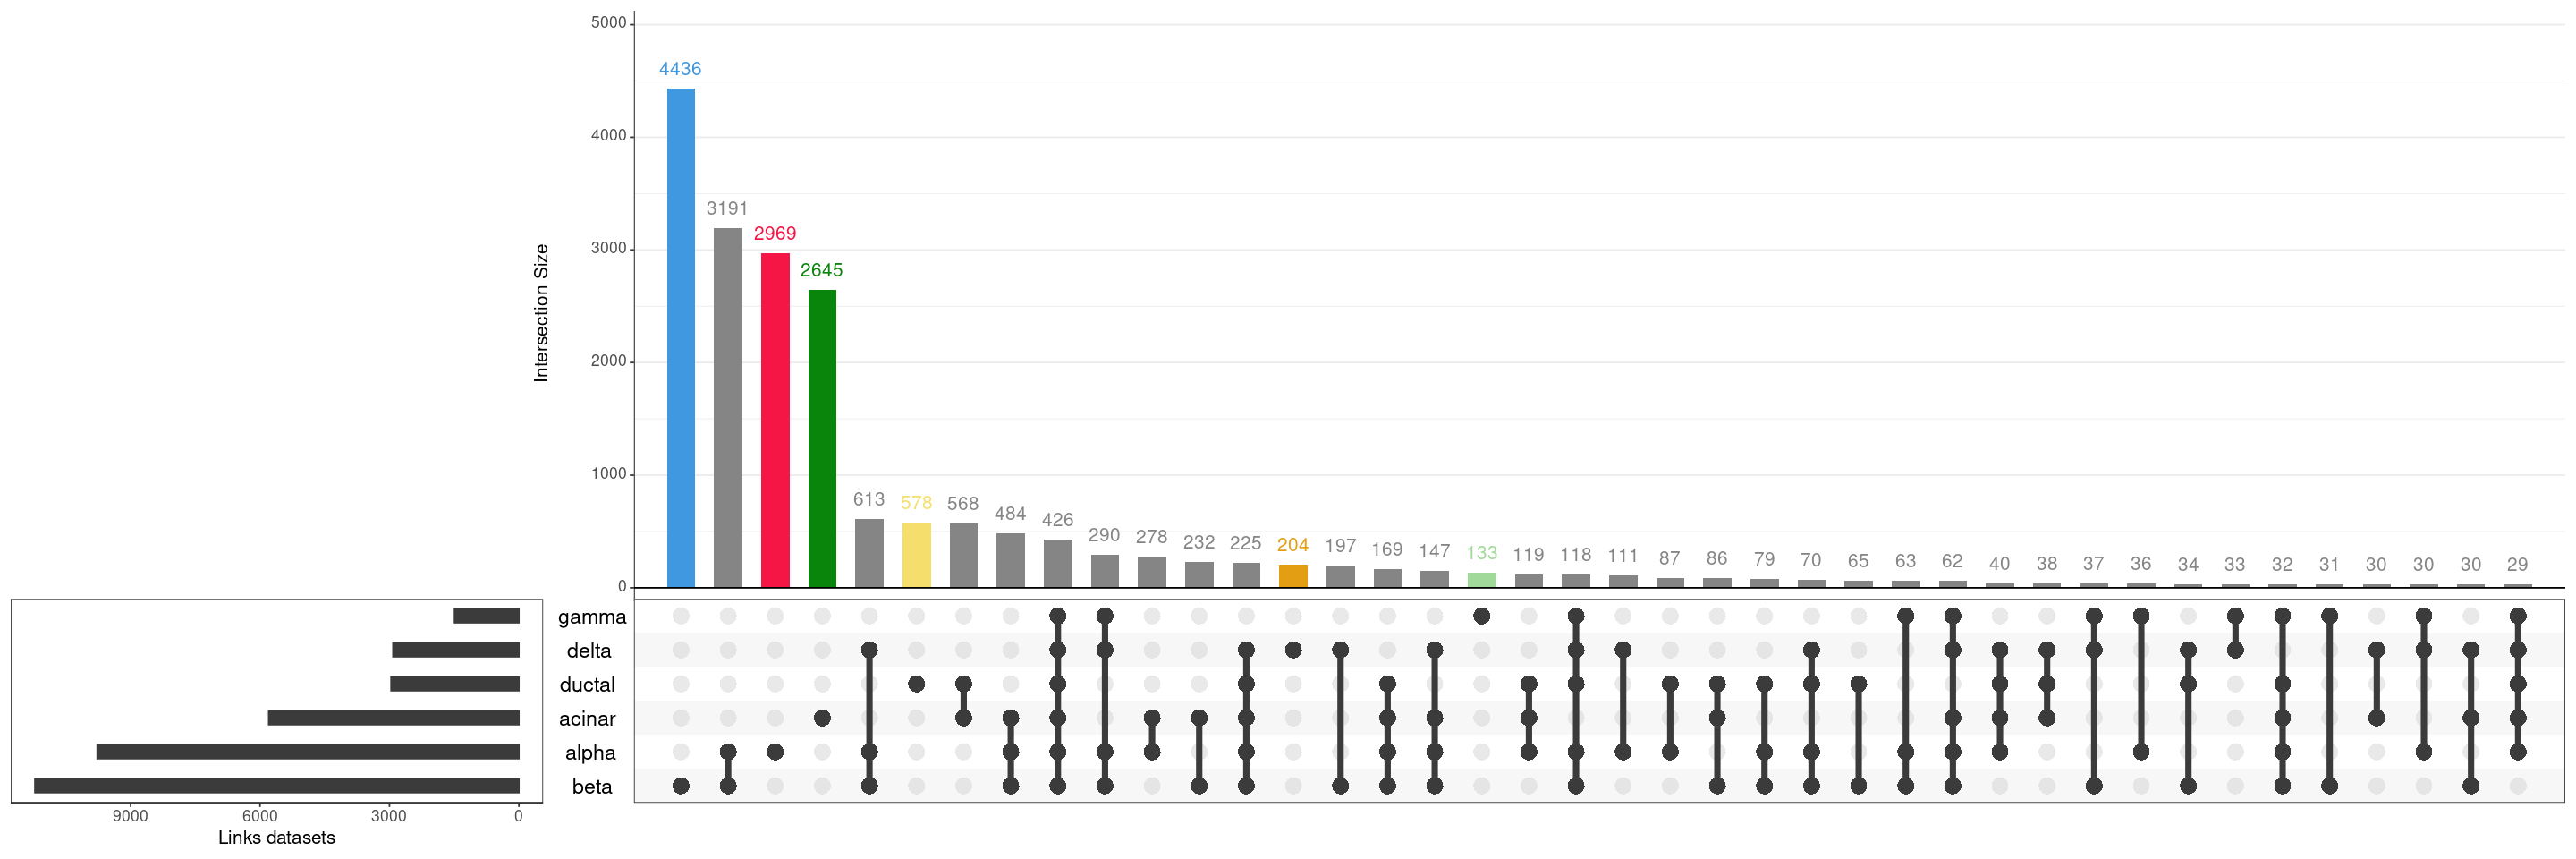

In [14]:
upset_plot_wrapper('SCARlink', sl_prefix, sl_suffix1)

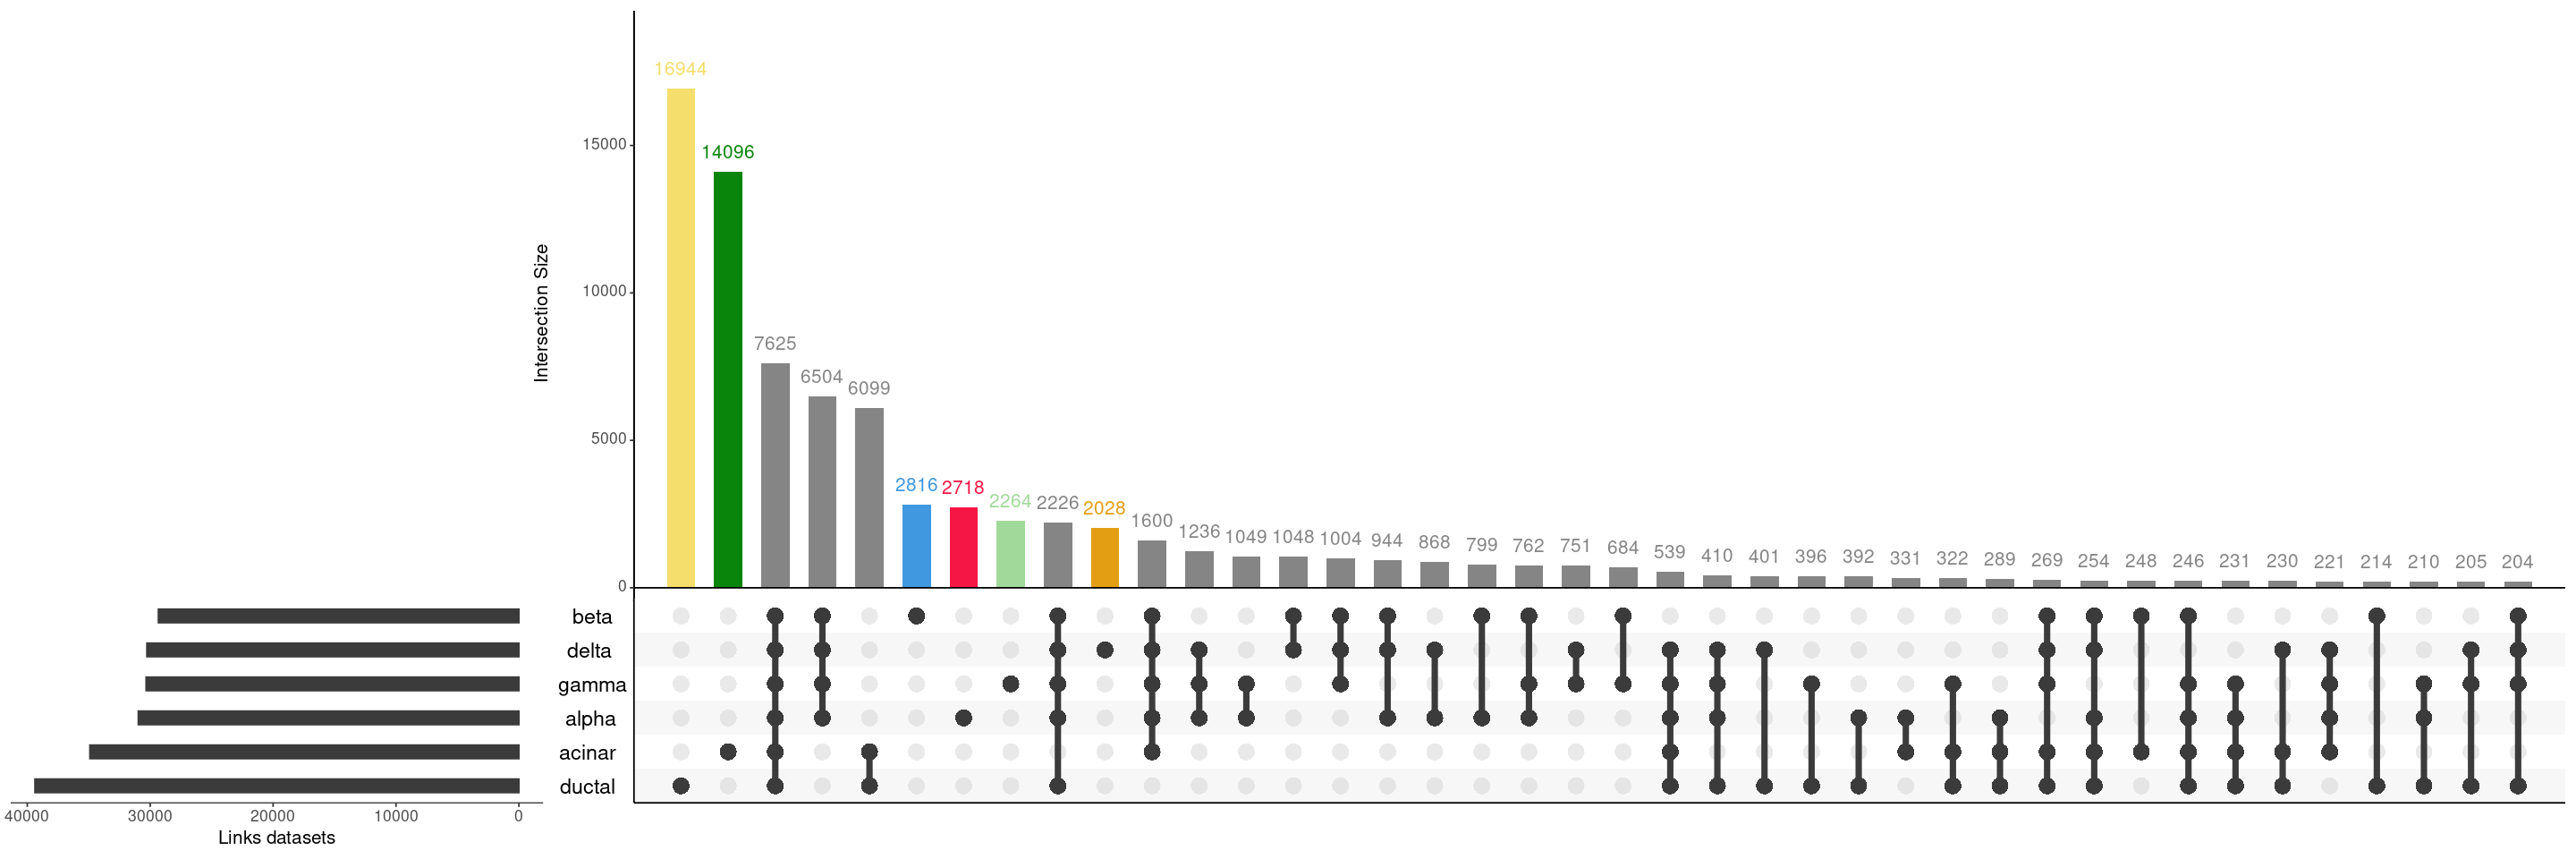

In [115]:
upset_plot_wrapper('ABC', abc_prefix1, abc_suffix1)

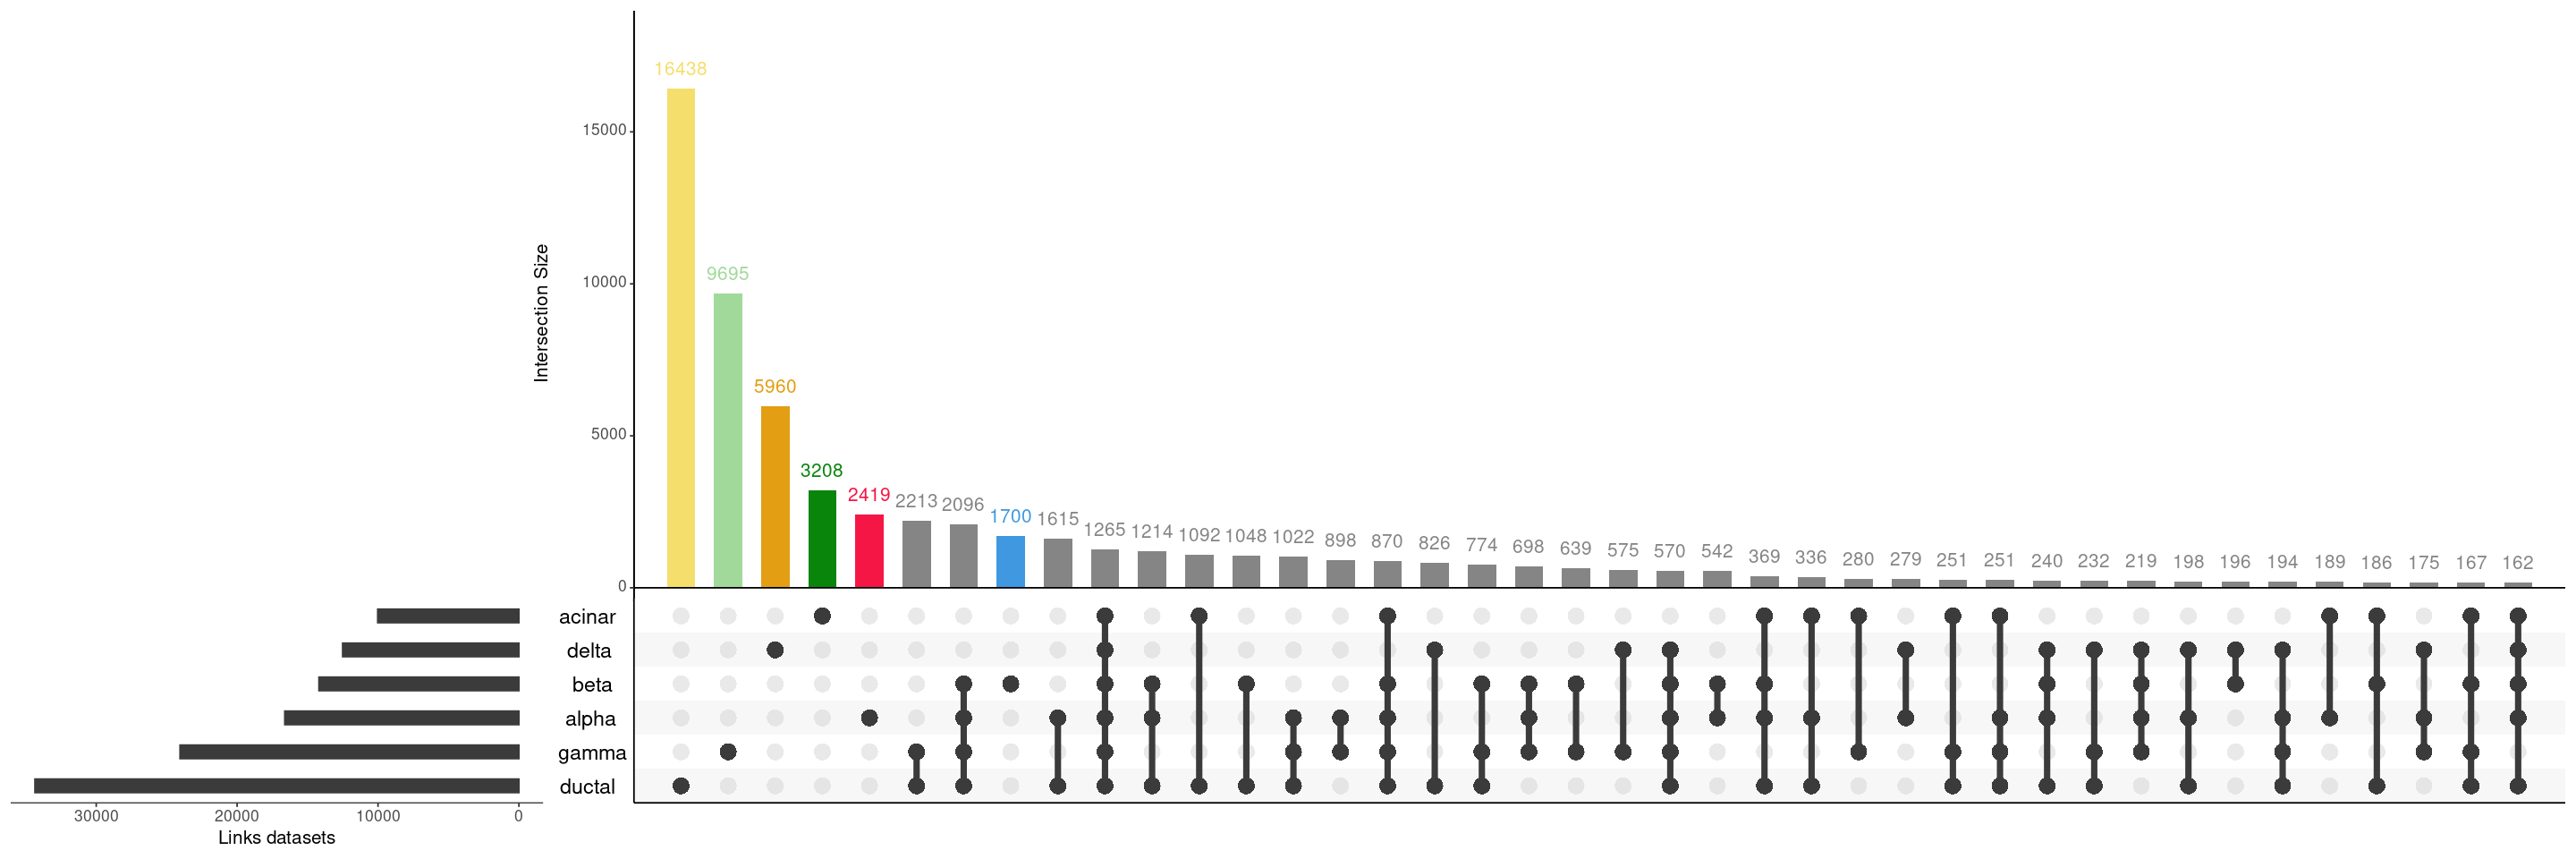

In [116]:
upset_plot_wrapper('Cicero', cic_prefix1, cic_suffix1)

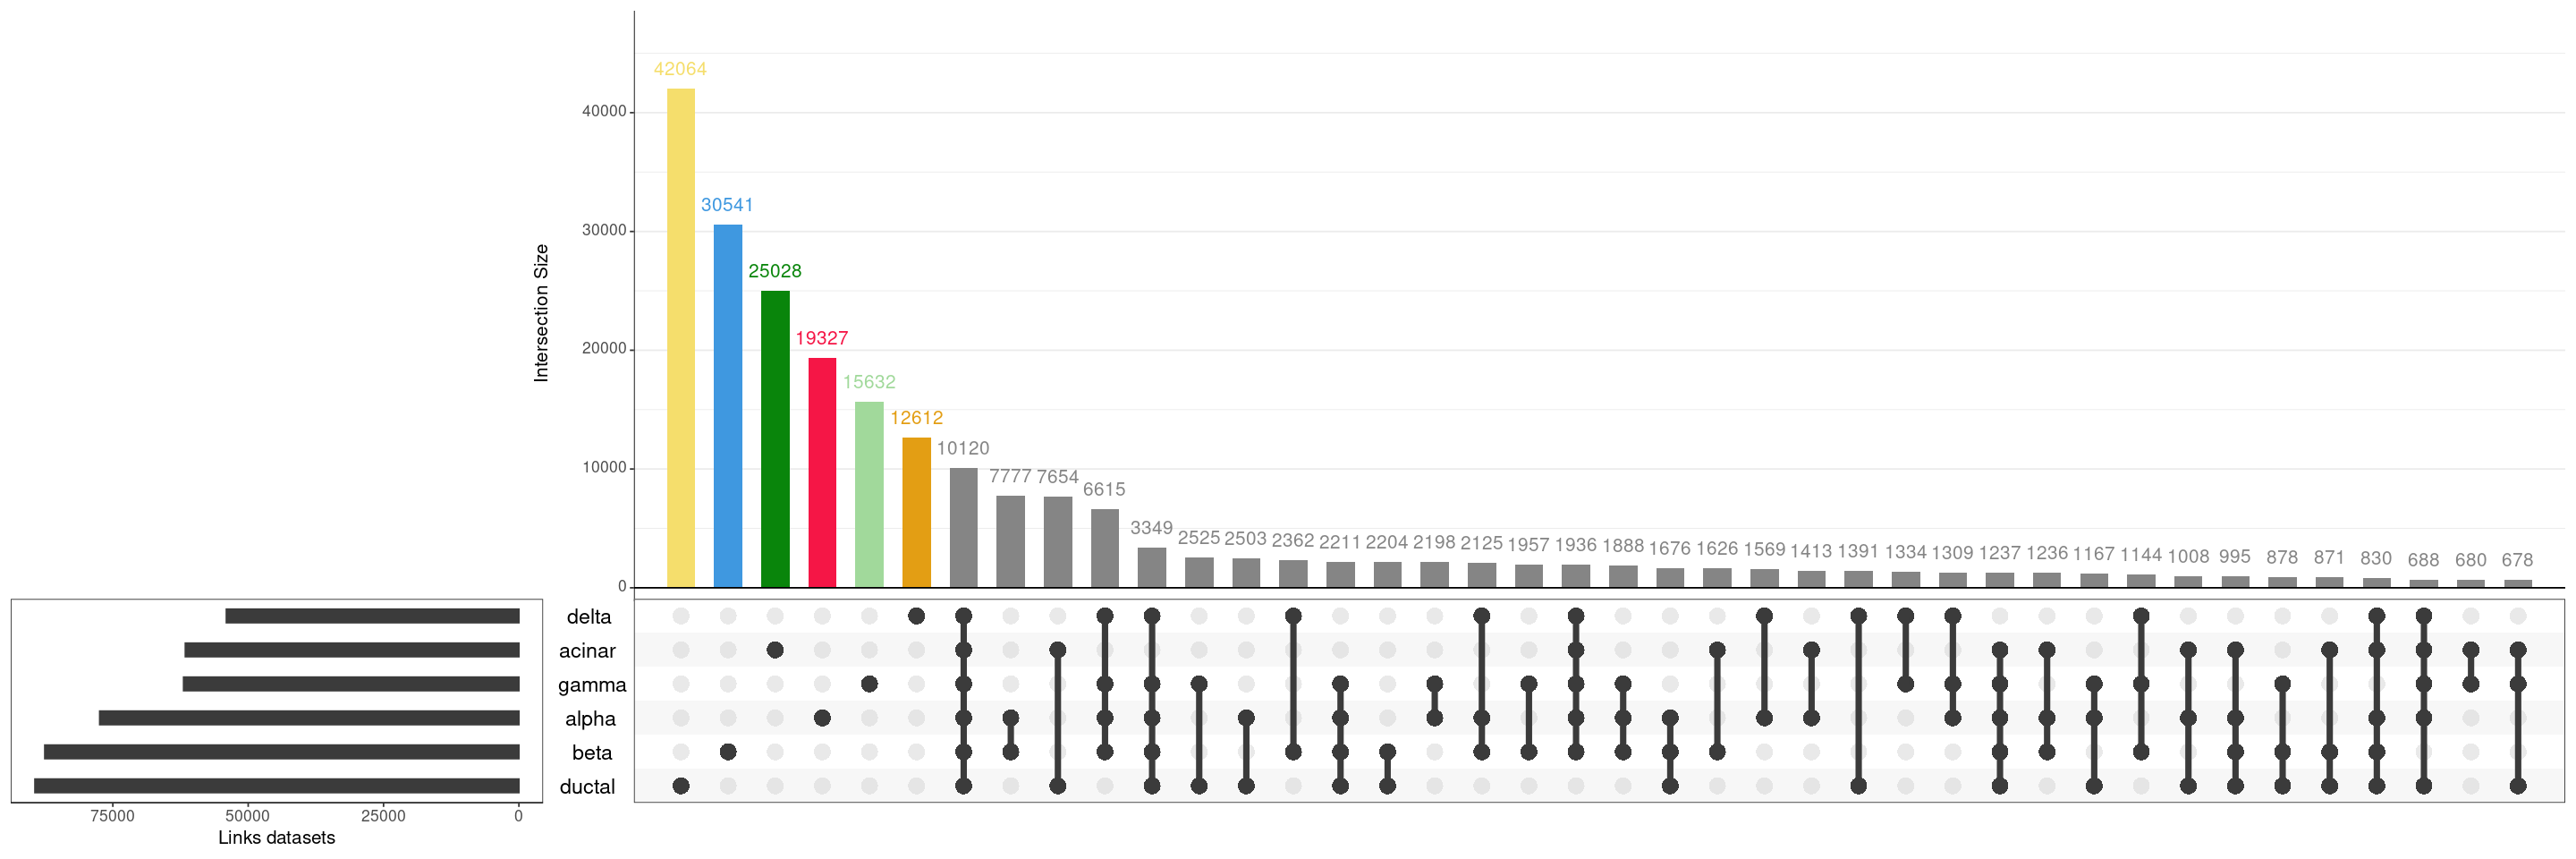

In [79]:
upset_plot_wrapper('All links', paste0(overlap_dir,'/'), '_all_methods_sig_links.bedpe')

In [2]:
sessionInfo()

R version 4.1.1 (2021-08-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.2 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/blas/libblas.so.3.9.0
LAPACK: /usr/lib/x86_64-linux-gnu/lapack/liblapack.so.3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] UpSetR_1.4.0      ggrepel_0.9.4     pheatmap_1.0.12   tictoc_1.1       
 [5] data.table_1.14.8 forcats_0.5.2     stringr_1.4.1     dplyr_1.0.10     
 [9] purrr_0.3.5       readr_2.1.1       tidyr_1.2.1       tibble_3.1.8     
[13] ggplot2_3.4.4     